In [71]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
import plotly.io as pio
import re

In [72]:
df = pd.read_csv("python_vacancies.csv")

# Clean data
df["employment"] = df["employment"].str.strip().str.lower().str.capitalize()
df["schedule"] = df["schedule"].str.strip().str.lower().str.capitalize()
df["work_hours"] = pd.to_numeric(df["work_hours"], errors="coerce")

# Extract max salary if numeric
def parse_salary_max(s):
    if pd.isna(s) or s == "Not specified":
        return None
    for part in str(s).split():
        if part.replace("–", "").replace("-", "").isdigit():
            if "–" in part or "-" in part:
                return int(part.split("–")[1] if "–" in part else part.split("-")[1])
            elif part.isdigit():
                return int(part)
    return None

df["salary_max"] = df["salary"].apply(parse_salary_max)

### Plot for EDA, not used in dashboard

C:\Users\DELL\AppData\Local\Temp\ipykernel_13880\2439480684.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




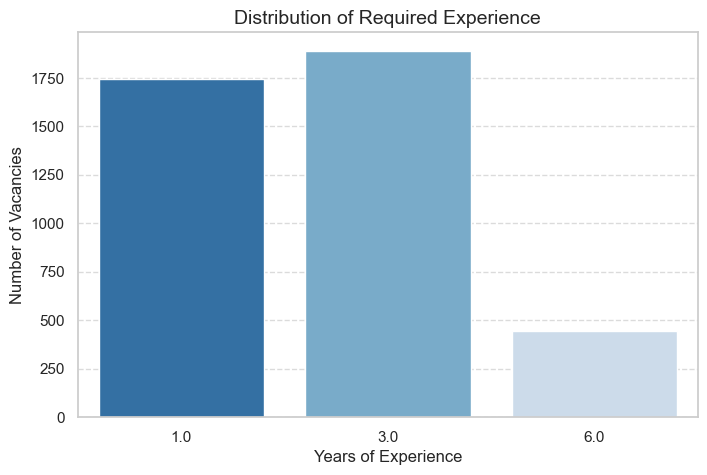

In [73]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="experience", palette="Blues_r", order=sorted(df["experience"].dropna().unique()))
plt.title("Distribution of Required Experience", fontsize=14)
plt.xlabel("Years of Experience")
plt.ylabel("Number of Vacancies")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

# Plot 1 - Employment Type Distribution

In [74]:
emp_counts = df["employment"].value_counts()
fig = px.pie(names=emp_counts.index, values=emp_counts.values, title="Employment Type Distribution")
fig.update_traces(textinfo='label+percent', pull=[0.05]*len(emp_counts))
fig.show()
pio.write_html(fig, file="charts/employment_pie.html", include_plotlyjs='cdn')

# Plot 2 - Job Title Breakdown

In [75]:
fig = px.treemap(df.dropna(subset=["employment"]), 
                 path=["employment", "title"], 
                 title="Job Title Breakdown by Employment Type")
fig.show()
pio.write_html(fig, file="charts/job_treemap.html", include_plotlyjs='cdn')

# Plot 3 - Top Python Job Titles

C:\Users\DELL\AppData\Local\Temp\ipykernel_13880\715661865.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




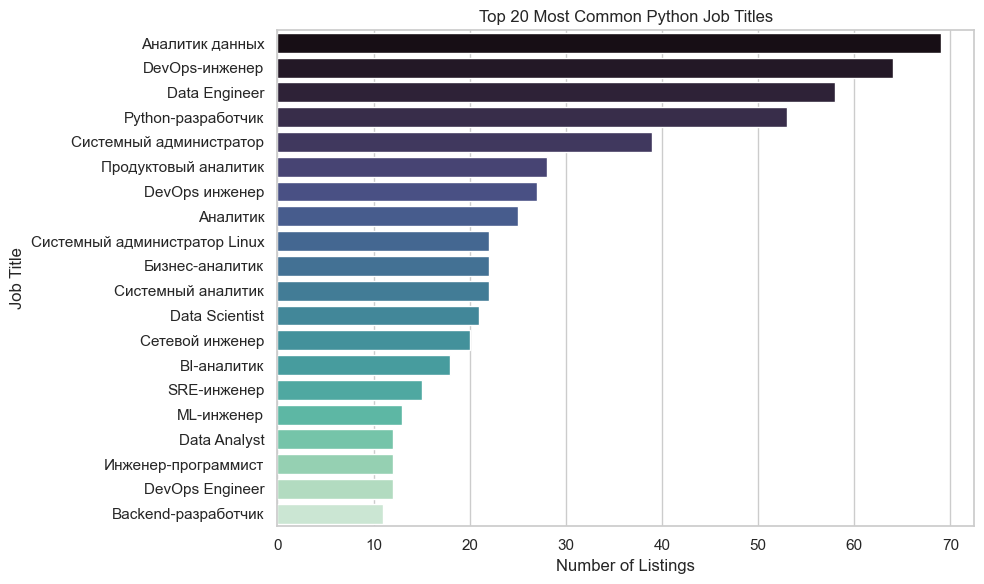

In [76]:
top_titles = df["title"].value_counts().nlargest(20)
plt.figure(figsize=(10, 6))
sns.barplot(y=top_titles.index, x=top_titles.values, palette="mako")
plt.title("Top 20 Most Common Python Job Titles")
plt.xlabel("Number of Listings")
plt.ylabel("Job Title")
plt.tight_layout()
plt.savefig("charts/top_titles.png", bbox_inches="tight", dpi=150)
plt.show()

# Plot 4 - Salary vs Experience

In [77]:
fig = px.box(df[df["salary_max"].notnull()], x="experience", y="salary_max",
             color="employment", points="outliers",
             title="Salary vs Experience by Employment Type",
             labels={"experience": "Years of Experience", "salary_max": "Max Salary (RUR)"})
fig.show()
pio.write_html(fig, file="charts/salary_boxplot.html", include_plotlyjs='cdn')

### Addintional plot, not used in dashboard

C:\Users\DELL\AppData\Local\Temp\ipykernel_13880\159260593.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\DELL\AppData\Local\Temp\ipykernel_13880\159260593.py:2: FutureWarning:

Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.



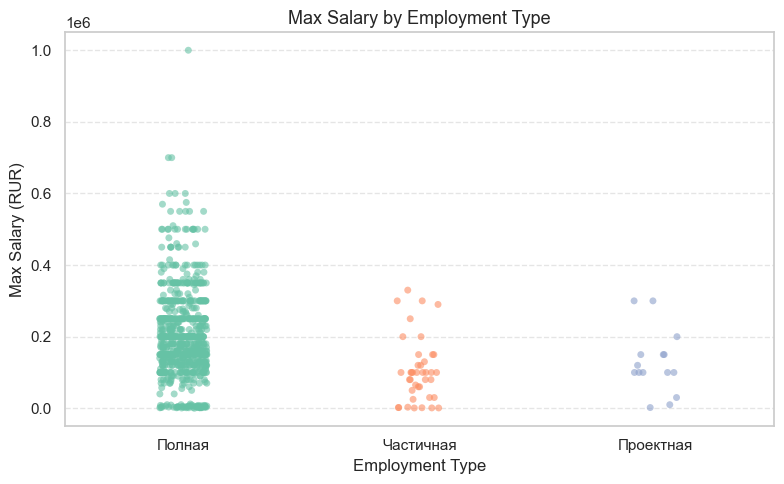

In [78]:
plt.figure(figsize=(8, 5))
sns.stripplot(data=df_scatter, x="employment", y="salary_max",
              jitter=True, alpha=0.6, palette="Set2", edgecolor="gray")

plt.title("Max Salary by Employment Type", fontsize=13)
plt.xlabel("Employment Type")
plt.ylabel("Max Salary (RUR)")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Plot 5 - Salary based on Experience and Employment type

In [79]:
# extract numeric salary
df["salary_numeric"] = df["salary"].apply(lambda s: int(re.search(r'(\d{4,7})', str(s).replace(" ", "").replace(",", "")).group(1))
                                          if pd.notna(s) and re.search(r'(\d{4,7})', str(s)) else None)

# encode employment types
employment_map = {val: i for i, val in enumerate(df["employment"].dropna().unique())}
df["employment_code"] = df["employment"].map(employment_map)
plot_df = df.dropna(subset=["experience", "employment_code", "salary_numeric"])

In [80]:
fig = go.Figure(data=[go.Scatter3d(
    x=plot_df["experience"],
    y=plot_df["employment_code"],
    z=plot_df["salary_numeric"],
    text=plot_df["title"],
    mode='markers',
    marker=dict(
        size=4,
        color=plot_df["salary_numeric"],
        colorscale='Viridis',
        opacity=0.8
    )
)])

fig.update_layout(
    title="Salary by Experience and Employment Type (3D)",
    scene=dict(
        xaxis_title='Experience (years)',
        yaxis_title='Employment Type',
        zaxis_title='Salary (RUR)',
        yaxis=dict(
            tickvals=list(employment_map.values()),
            ticktext=list(employment_map.keys())
        )
    ),
    margin=dict(l=20, r=20, b=20, t=50)
)

fig.show()
pio.write_html(fig, file="charts/salary_3d.html", include_plotlyjs='cdn')